In [1]:
# in python vector can be represented in various wwasts, the simpllest being a regular list of numbers 

In [ ]:
vector = [1,2,3,4,5,6]

In [7]:
import numpy as np 
vector = np.array([10,15,20,44.4])
vector

array([10. , 15. , 20. , 44.4])

In [9]:
vector.size

4

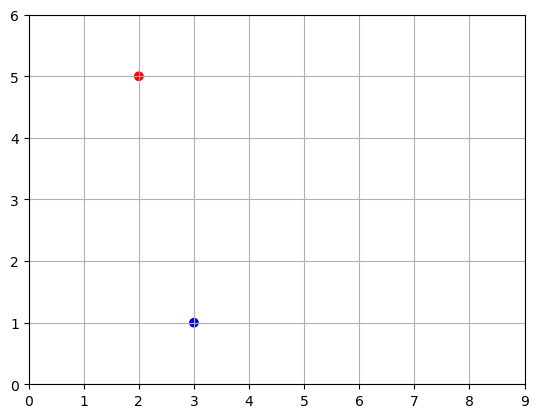

In [41]:
# plotting vectors 
import matplotlib.pyplot as plt 
u = np.array([2,5])
v = np.array([3,1])
x,y = zip(u,v)
plt.scatter(x,y,color=['r','b'])
plt.axis([0,9,0,6])
plt.grid()
plt.show()

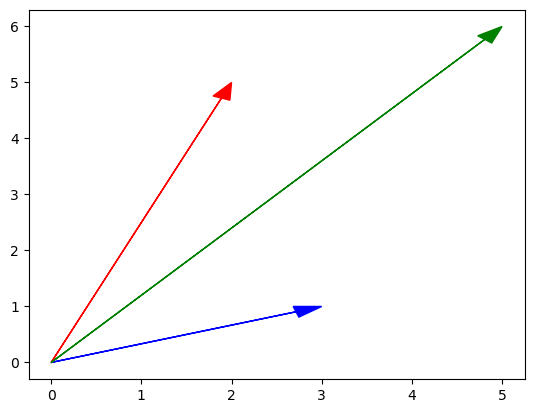

In [42]:
def plot_vector2d(vector2d, origin=[0, 0], **options):
    return plt.arrow(origin[0], origin[1], vector2d[0], vector2d[1],
              head_width=0.2, head_length=0.3, length_includes_head=True,
              **options)


plot_vector2d(u, color="r")
plot_vector2d(v, color="b")
plot_vector2d(u+v, color="g")


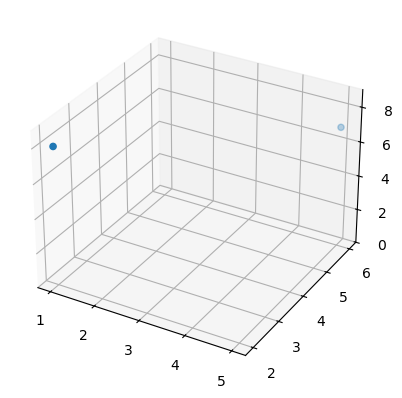

In [43]:
# 3d plots 
a = np.array([1,2,8])
b = np.array([5,6,7])
subplot3d = plt.subplot(111,projection='3d')
x_coord, y_coords, z_coords = zip(a,b)
subplot3d.scatter(x_coord, y_coords, z_coords)
subplot3d.set_zlim3d([0,9])
plt.show()

## Norm
The norm of a vector $\textbf{u}$, noted $\left \Vert \textbf{u} \right \|$, is a measure of the length (a.k.a. the magnitude) of $\textbf{u}$. There are multiple possible norms, but the most common one (and the only one we will discuss here) is the Euclidian norm, which is defined as:

$\left \Vert \textbf{u} \right \| = \sqrt{\sum_{i}{\textbf{u}_i}^2}$

That's the square root of the sum of all the squares of the components of $\textbf{u}$. We could implement this easily in pure python, recalling that $\sqrt x = x^{\frac{1}{2}}$

In [44]:
def vector_norm(vector):
    squares = [element ** 2 for element in vector]
    return sum(squares) ** 0.5
print("||",u,"|| = ")
vector_norm(u)

|| [2 5] || = 


5.385164807134504

In [49]:
# however the much more efficeiet method is to use Nympy norrm function available in the linalg module
import numpy.linalg as LA
LA.norm(u)

5.385164807134504

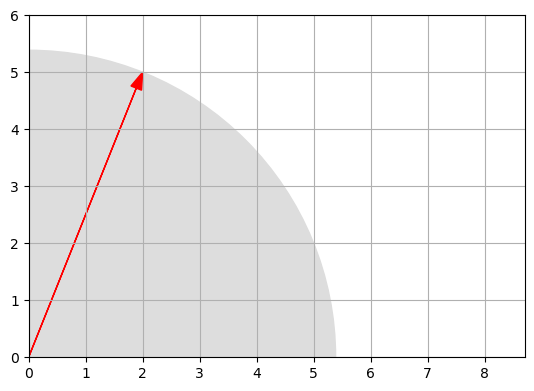

In [50]:
radius = LA.norm(u)
plt.gca().add_artist(plt.Circle((0,0), radius, color="#DDDDDD"))
plot_vector2d(u, color="red")
plt.axis([0, 8.7, 0, 6])
plt.gca().set_aspect("equal")
plt.grid()
plt.show()

In [52]:
# vector addition 
# vector of same size can be added together

u + v

array([5, 6])

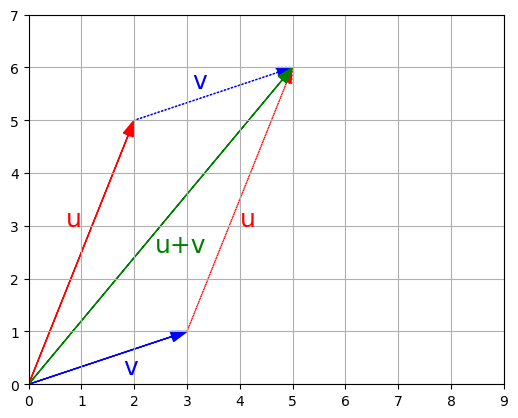

In [53]:
plot_vector2d(u, color="r")
plot_vector2d(v, color="b")
plot_vector2d(v, origin=u, color="b", linestyle="dotted")
plot_vector2d(u, origin=v, color="r", linestyle="dotted")
plot_vector2d(u+v, color="g")
plt.axis([0, 9, 0, 7])
plt.gca().set_aspect("equal")
plt.text(0.7, 3, "u", color="r", fontsize=18)
plt.text(4, 3, "u", color="r", fontsize=18)
plt.text(1.8, 0.2, "v", color="b", fontsize=18)
plt.text(3.1, 5.6, "v", color="b", fontsize=18)
plt.text(2.4, 2.5, "u+v", color="g", fontsize=18)
plt.grid()
plt.show()

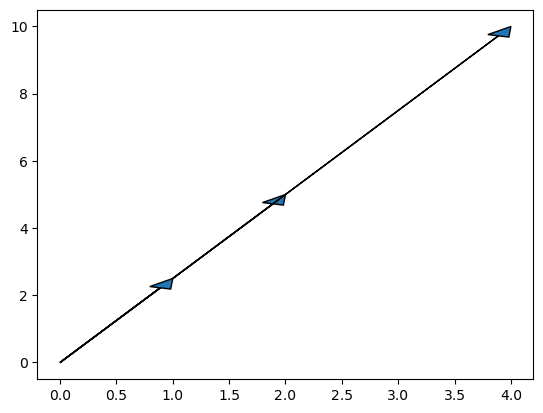

In [60]:
# multiplication 
# vectors can be multipled by scalars. all the elements will be multipled 
k = 2
b = k * u
c = u / k
plot_vector2d(u)
plot_vector2d(b)
plot_vector2d(c)



## Zero, unit and normalized vectors
* A **zero-vector** is a vector full of 0s.
* A **unit vector** is a vector with a norm equal to 1.
* The **normalized vector** of a non-null vector $\textbf{v}$, noted $\hat{\textbf{v}}$, is the unit vector that points in the same direction as $\textbf{v}$. It is equal to: $\hat{\textbf{v}} = \dfrac{\textbf{v}}{\left \Vert \textbf{v} \right \|}$



### Dot product(also called scalar product or inner product in the context of the Euclidian Space) of two vectors u and v 
$\textbf{u} \cdot \textbf{v} = \left \Vert \textbf{u} \right \| \times \left \Vert \textbf{v} \right \| \times cos(\theta)$


In [63]:
def dot_product(v1,v2):
    return sum([i * j for i, j in zip(v1,v2)])

dot_product(u,v)

11

In [64]:
# but for efficiency 
np.dot(u,v)

11

### Main properties
* The dot product is **commutative**: $\textbf{u} \cdot \textbf{v} = \textbf{v} \cdot \textbf{u}$.
* The dot product is only defined between two vectors, not between a scalar and a vector. This means that we cannot chain dot products: for example, the expression $\textbf{u} \cdot \textbf{v} \cdot \textbf{w}$ is not defined since $\textbf{u} \cdot \textbf{v}$ is a scalar and $\textbf{w}$ is a vector.
* This also means that the dot product is **NOT associative**: $(\textbf{u} \cdot \textbf{v}) \cdot \textbf{w} ≠ \textbf{u} \cdot (\textbf{v} \cdot \textbf{w})$ since neither are defined.
* However, the dot product is **associative with regards to scalar multiplication**: $\lambda \times (\textbf{u} \cdot \textbf{v}) = (\lambda \times \textbf{u}) \cdot \textbf{v} = \textbf{u} \cdot (\lambda \times \textbf{v})$
* Finally, the dot product is **distributive** over addition of vectors: $\textbf{u} \cdot (\textbf{v} + \textbf{w}) = \textbf{u} \cdot \textbf{v} + \textbf{u} \cdot \textbf{w}$.

### Calculating the angle between vectors
One of the many uses of the dot product is to calculate the angle between two non-zero vectors. Looking at the dot product definition, we can deduce the following formula:

$\theta = \arccos{\left ( \dfrac{\textbf{u} \cdot \textbf{v}}{\left \Vert \textbf{u} \right \| \times \left \Vert \textbf{v} \right \|} \right ) }$

Note that if $\textbf{u} \cdot \textbf{v} = 0$, it follows that $\theta = \dfrac{π}{2}$. In other words, if the dot product of two non-null vectors is zero, it means that they are orthogonal.

Let's use this formula to calculate the angle between $\textbf{u}$ and $\textbf{v}$ (in radians):

In [68]:
def vector_angle(u,v):
    cost_theta = np.dot(u,v) / LA.norm(u) // LA.norm(v)
    return np.arccos(cost_theta.clip(-1,1))

theta = vector_angle(u,v)
theta * 180 / np.pi
# Note: due to small floating point errors, 
# `cos_theta` may be very slightly outside 
# the $[-1, 1]$ interval, which would make 
# `arccos` fail. This is why we clipped the value
#  within the range, using NumPy's `clip` function.

90.0

# Matrices
A matrix is a rectangular array of scalars (i.e. any number: integer, real or complex) arranged in rows and columns, for example:

\begin{bmatrix} 10 & 20 & 30 \\ 40 & 50 & 60 \end{bmatrix}

You can also think of a matrix as a list of vectors: the previous matrix contains either 2 horizontal 3D vectors or 3 vertical 2D vectors.

Matrices are convenient and very efficient to run operations on many vectors at a time. We will also see that they are great at representing and performing linear transformations such rotations, translations and scaling.

In [71]:
# Simiply it's ia a nD list 
[
    [10, 20, 30],
    [40, 50, 60]
]


[[10, 20, 30], [40, 50, 60]]

In [73]:
A = np.array([
    [10, 20, 30],
    [40, 50, 60]
])
A

array([[10, 20, 30],
       [40, 50, 60]])

In [77]:
print(A.shape)
print(A.size)


(2, 3)
6


## Element indexing
The number located in the $i^{th}$ row, and $j^{th}$ column of a matrix $X$ is sometimes noted $X_{i,j}$ or $X_{ij}$, but there is no standard notation, so people often prefer to explicitly name the elements, like this: "*let $X = (x_{i,j})_{1 ≤ i ≤ m, 1 ≤ j ≤ n}$*". This means that $X$ is equal to:

$X = \begin{bmatrix}
  x_{1,1} & x_{1,2} & x_{1,3} & \cdots & x_{1,n}\\
  x_{2,1} & x_{2,2} & x_{2,3} & \cdots & x_{2,n}\\
  x_{3,1} & x_{3,2} & x_{3,3} & \cdots & x_{3,n}\\
  \vdots & \vdots & \vdots & \ddots & \vdots \\
  x_{m,1} & x_{m,2} & x_{m,3} & \cdots & x_{m,n}\\
\end{bmatrix}$

However, in this notebook we will use the $X_{i,j}$ notation, as it matches fairly well NumPy's notation. Note that in math indices generally start at 1, but in programming they usually start at 0. So to access $A_{2,3}$ programmatically, we need to write this:

In [83]:
print(A[1,2]) # 2nd row, 3r column
print(A[1,:])


60
[40 50 60]


In [87]:
# Matrix Multiplication 
D = np.array([
        [ 2,  3,  5,  7],
        [11, 13, 17, 19],
        [23, 29, 31, 37]
    ])
E = np.matmul(A,D)
E

array([[ 930, 1160, 1320, 1560],
       [2010, 2510, 2910, 3450]])

In [88]:
# simpply
A @ D

array([[ 930, 1160, 1320, 1560],
       [2010, 2510, 2910, 3450]])

In [89]:
# transpose 
E.T

array([[ 930, 2010],
       [1160, 2510],
       [1320, 2910],
       [1560, 3450]])

In [93]:
# determinants
B = [[1,2,3,5],[1,2,5,4],[2,3,3,4],[18,2,3,3]] 
LA.det(B)

284.99999999999955

## Determinant
The determinant of a square matrix $M$, noted $\det(M)$ or $\det M$ or $|M|$ is a value that can be calculated from its elements $(M_{i,j})$ using various equivalent methods. One of the simplest methods is this recursive approach:

$|M| = M_{1,1}\times|M^{(1,1)}| - M_{1,2}\times|M^{(1,2)}| + M_{1,3}\times|M^{(1,3)}| - M_{1,4}\times|M^{(1,4)}| + \cdots ± M_{1,n}\times|M^{(1,n)}|$

* Where $M^{(i,j)}$ is the matrix $M$ without row $i$ and column $j$.

For example, let's calculate the determinant of the following $3 \times 3$ matrix:

$M = \begin{bmatrix}
  1 & 2 & 3 \\
  4 & 5 & 6 \\
  7 & 8 & 0
\end{bmatrix}$

Using the method above, we get:

$|M| = 1 \times \left | \begin{bmatrix} 5 & 6 \\ 8 & 0 \end{bmatrix} \right |
     - 2 \times \left | \begin{bmatrix} 4 & 6 \\ 7 & 0 \end{bmatrix} \right |
     + 3 \times \left | \begin{bmatrix} 4 & 5 \\ 7 & 8 \end{bmatrix} \right |$

Now we need to compute the determinant of each of these $2 \times 2$ matrices (these determinants are called **minors**):

$\left | \begin{bmatrix} 5 & 6 \\ 8 & 0 \end{bmatrix} \right | = 5 \times 0 - 6 \times 8 = -48$

$\left | \begin{bmatrix} 4 & 6 \\ 7 & 0 \end{bmatrix} \right | = 4 \times 0 - 6 \times 7 = -42$

$\left | \begin{bmatrix} 4 & 5 \\ 7 & 8 \end{bmatrix} \right | = 4 \times 8 - 5 \times 7 = -3$

Now we can calculate the final result:

$|M| = 1 \times (-48) - 2 \times (-42) + 3 \times (-3) = 27$